# **Radial Metallicity Relations in Simulations**

Code component of Question 3 of ASTR4004 Problem Set 2. See assignment write-up for full answer to Question 3.

**The radial metallicity relation describes the change of metallicity - here, the gas-phase metallicity $A(\mathrm{O}) = \log_{10}(N_\mathrm{O}\,/\,N_\mathrm{H}) + 12$ - which Galactocentric cylindrical radius, $R_\mathrm{Gal}$. Radial metallicity gradients provide insight into processes such as inside-out formation, gas accretion, outflows, and radial migration. A lot of work has been done through observational studies and a few simulations, but more work is needed to understand variations of the radial metallicity gradient.**

**Your colleague has completed a cosmological simulation of a MW-like spiral galaxy. The `.fits` file `data/nihao_uhd_simulation_g8.26` `e11_xyz_positions_and_oxygen_ao.fits` contains the gas-phase metallicity $A(\mathrm{O})$ and $(x,\,y,\,z)$ positions of gas particles within $R_\mathrm{Gal} = \sqrt{x^2 + y^2} < 25\,\mathrm{kpc}$. Perform the following tasks and save your figures in `figures/`.**

## **PART A**

**Plot a two-panel figure: logarithmic density plot of $R_\mathrm{Gal}$ vs $A(\mathrm{O})$, with a linear fit and a legend; residuals of the fit, $R_\mathrm{Gal}$ vs $\Delta A(\mathrm{O})$.**

Import necessary packages.

In [83]:
# packages handling arrays
import numpy as np
import pandas as pd
# package for data visualisation
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm # for log cmaps
from matplotlib.colors import LinearSegmentedColormap
cmap_colours = ["mediumvioletred", "darkred"]
cmap = LinearSegmentedColormap.from_list(
    "cmap",
    ["white", cmap_colours[0], cmap_colours[1]]
) # set standard cmap
# astropy for handling data in .fits format
from astropy.io import fits
# packages for model fitting
import scipy as sp
import emcee as mc
# functions to format math in outputs
from IPython.display import display, Math

Read-in data to a `np.array()`.

In [78]:
# read-in to file (containing header/metadata)
data_file = fits.open("data/q3_simulation_data.fits")
# extract data
data = np.array(data_file[1].data)

Prepare figure axes variables.

In [103]:
x = np.sqrt((data["x"])**2 + (data["y"])**2) # R_Gal (same for both panels)
y_main = data["A_O"] # A(O)
fit_res = np.polyfit(x, y_main, 1) # linear fit (deg=1), returns [m, b]
y_fit = (fit_res[0])*x + fit_res[1] # y = mx + b
y_resid = y_main - y_fit

# binning values
binsize = 100
counts_main, x_edges, y_edges_main = np.histogram2d(x, y_main, bins=binsize) # main histogram
counts_resid, _, y_edges_resid = np.histogram2d(x, y_resid, bins=binsize) # residuals histogram

Create 2-panel figure and save.

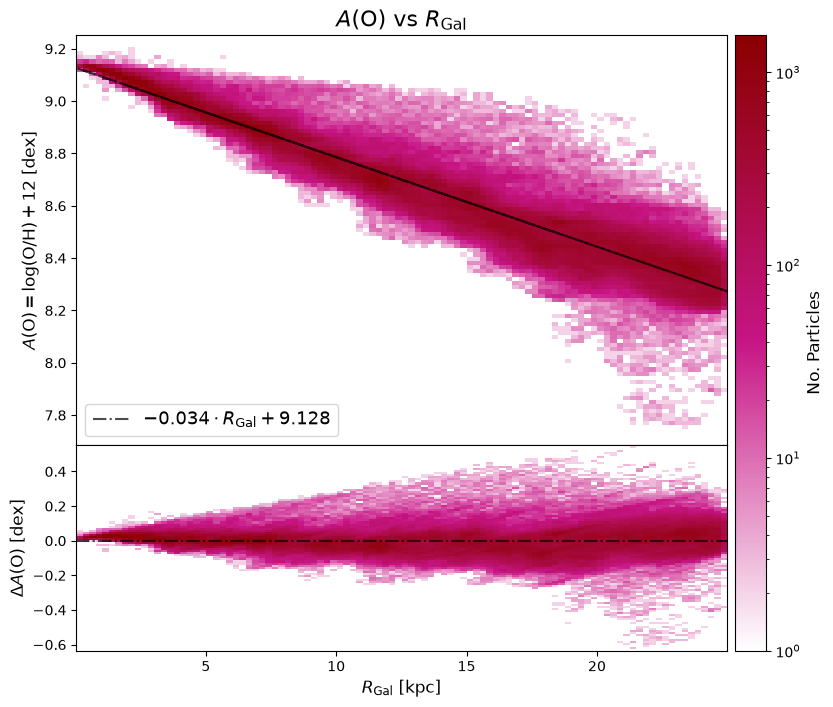

In [104]:
# define figure with two vertically-stacked subplots
fig, axs = plt.subplots(2, 1, figsize=(10,8), sharex=True, sharey=False, gridspec_kw={"height_ratios": [2, 1], "hspace": 0})

# main (left) panel
ax = axs[0]
image = ax.pcolormesh(x_edges, y_edges_main, counts_main.T, cmap=cmap, norm=LogNorm(), shading="auto") # plot 2D hist
ax.plot(x, y_fit, lw=1.5, marker="", c="black", label=rf"${fit_res[0]:.3f}\cdot R_\mathrm{{Gal}} + {fit_res[1]:.3f}$", ls="-.", alpha=0.7)
ax.set_title(r"$A(\mathrm{O})$ vs $R_\mathrm{Gal}$", fontsize=16) # panel title
ax.set_ylabel(r"$A(\mathrm{O}) = \log(\mathrm{O}/\mathrm{H}) + 12$ [dex]", fontsize=12) # y axis label
ax.legend(loc="lower left", fontsize=13)

# residuals (right) panel
ax = axs[1]
ax.pcolormesh(x_edges, y_edges_resid, counts_resid.T, cmap=cmap, norm=LogNorm(), shading="auto")
ax.axhline(0, c="black", lw=1.5, ls="-.", alpha=0.7)
ax.set_ylabel(r"$\Delta A(\mathrm{O})$ [dex]", fontsize=12)
ax.set_xlabel(r"$R_\mathrm{Gal}$ [kpc]", fontsize=12) # x axis label
cbar = fig.colorbar(image, ax=axs, pad=0.01)
cbar.set_label("No. Particles", fontsize=12)

plt.savefig("figures/q3a_gasphase.png", dpi=200) # save to figures/
plt.show() # display figure

## **PART B**

**Use a `Python` fitting tool to fit a linear function to the data, reporting the intercept and slope with uncertainties. Include any hyperparameters used.**

Define necessary functions for MCMC analysis.

In [85]:
# linear relation
def model(theta, x):
    """
    Defines linear relationship between "A_O" and "R_Gal".
    Inputs:
        theta = model parameters (gradient/slope "m", intercept "b", log intrinsic scatter "ln_sigma")
        x = input observable ("R_Gal") 
    Outputs:
        y = output observable ("A_O")
    """
    m, b, _ = theta
    R_Gal = x
    A_O = m * R_Gal + b
    return A_O

# parameters priors (advised by quick analysis in PART A)
def log_prior(theta):
    """
    Defines bounds for the MCMC walkers of each model parameter.
    Inputs:
        theta = model parameters (gradient/slope "m", intercept "b", log intrinsic scatter "ln_sigma")
    Outputs:
        log probability (ln(1) = 0 if theta in bounds, ln(0) = -inf if not)
    """
    m, b, ln_sigma = theta
    if (-0.2 < m < 0.1) and (6 < b < 12) and (-5 < ln_sigma < 2):
        return 0.0 # ln(1)
    else:
        return -np.inf # ln(0)

# likelihood function
def log_likelihood(theta, x, y):
    """
    Calculate likelihood of observing each "R_Gal" and "A_O" given the model parameters.
    Inputs:
        theta = model parameters (gradient/slope "m", intercept "b", log intrinsic scatter "ln_sigma")
        x = input observable ("R_Gal") 
        y = output observable ("A_O")
    Outputs:
        log probability 
    """
    _, _, ln_sigma = theta
    sigma = np.exp(ln_sigma) # de-log ln_sigma
    var = sigma**2 # variance

    y_model = model(theta, x) # model-predicted "A_O" values at each "R_Gal"
    resids = y - y_model # distance between model-predicted "A_O" and observed "A_O"

    ln_L = -0.5 * np.sum(np.log(2*np.pi*var) + resids**2/var)
    return ln_L

# posterior probability
def log_probability(theta, x, y):
    """
    Calculate the resultant probability of a model parameter set (including priors and likelihood).
    Inputs:
        theta = model parameters (gradient/slope "m", intercept "b", log intrinsic scatter "ln_sigma")
        x = input observable ("R_Gal") 
        y = output observable ("A_O")
    Outputs:
        log probability (ln(0) = -inf if model rejected by priors, log likelihood if model suitable since log prior = 0)
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf # ln(0)
    else:
        ll = log_likelihood(theta, x, y)
        return ll # log likelihood

Determine initial positions for MCMC walkers.

In [86]:
# scipy linear regression
fit_res = sp.stats.linregress(x, y_main) # input R_Gal and A(O)

m_init = fit_res.slope # initial gradient/slope
b_init = fit_res.intercept # initial intercept

resids = y_main - (m_init * x + b_init)
sigma_init = np.std(resids) # initial intrinsic scatter

# print initial values
print("Initial values:")
display(Math(f"$m = {m_init:.4f}$"))
display(Math(f"$b = {b_init:.4f}$"))
display(Math(rf"$\sigma_\mathrm{{int}} = {sigma_init:.4f}$"))

Initial values:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Implement the MCMC analysis.

In [87]:
ndim = 3
nwalkers = 32 # > 2*ndim to sample sufficiently
nsteps = 5000

initial = np.array([m_init, b_init, np.log(sigma_init)]) # array of the central positions
perturbs = 1e-3 * np.random.randn(nwalkers, ndim) # define normal distribution of perturbations
positions = initial + perturbs # shift these perturbations to around central positions

# run MCMC sampling
sampler = mc.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y_main))
sampler.run_mcmc(positions, nsteps, progress=True)
samples = sampler.get_chain(
    discard=1000, # discard first positions of each walker
    flat=True # flatten nwalkers and nsteps into 1D array
)

100%|██████████| 5000/5000 [03:54<00:00, 21.35it/s]


Extract the median and $1\sigma$ values for each model parameter.

In [88]:
# read each samples array from full samples results
m_samples = samples[:,0]
b_samples = samples[:,1]
sigma_samples = np.exp(samples[:,2])

# extract percentiles
m_lo, m_med, m_hi = np.percentile(m_samples, [16, 50, 84])
b_lo, b_med, b_hi = np.percentile(b_samples, [16, 50, 84])
sigma_lo, sigma_med, sigma_hi = np.percentile(sigma_samples, [16, 50, 84])

# print results
display(Math(rf"$m = {1e2*m_med:.4f}_{{-{1e2*(m_med-m_lo):.4f}}}^{{+{1e2*(m_hi-m_med):.4f}}} \times 10^{{-2}}\,\mathrm{{dex}}\,\mathrm{{kpc}}^{{-1}}$"))
display(Math(rf"$b = {b_med:.5f}_{{-{(b_med-b_lo):.5f}}}^{{+{(b_hi-b_med):.5f}}}\,\mathrm{{dex}}$"))
display(Math(rf"$\sigma_\mathrm{{int}} = {1e2*sigma_med:.4f}_{{-{1e2*(sigma_med-sigma_lo):.4f}}}^{{+{1e2*(sigma_hi-sigma_med):.4f}}} \times 10^{{-2}}\,\mathrm{{dex}}$"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## **PART C**

**Discuss where the linear model fits well and where it does not. Use statistical metrics to quantify its performance overall and in regions with larger residuals.**

Compute RMSE.

In [100]:
# compute MCMC residuals
mcmc_y = m_med * x + b_med
mcmc_resids = y_main - mcmc_y

# compute RMSE
rmse = np.sqrt(np.mean(mcmc_resids**2))
print(f"RMSE = {rmse:.4f} dex")

RMSE = 0.0726 dex


Compute RMSE in radial bins.

In [101]:
# define radial bins of width 0.5kpc
bins = np.arange(0, 25.5, 0.5)

# determine rmse in each bin
centre_array = []
rmse_array = []
for r_min, r_max in zip(bins[:-1], bins[1:]):
    mask = (x >= r_min) & (x < r_max) # only include partial in given radial bin
    rmse_bin = np.sqrt(np.mean(mcmc_resids[mask]**2))
    centre_array.append(np.mean([r_min, r_max])) # bin centres
    rmse_array.append(rmse_bin)
centre_array = np.array(centre_array)
rmse_array = np.array(rmse_array)

Plot intrinsic scatter and RMSE of residuals.

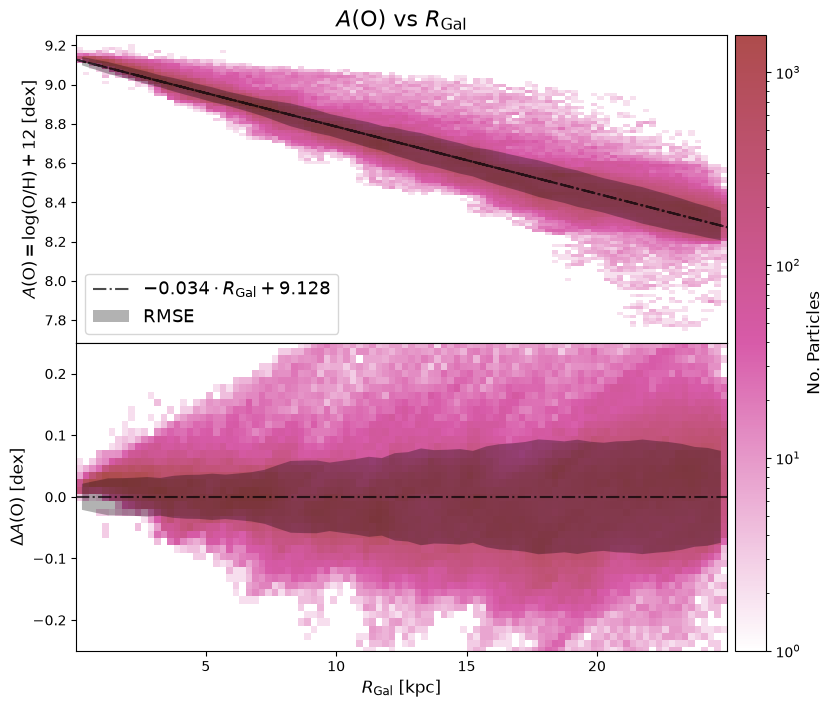

In [110]:
fig, axs = plt.subplots(2, 1, figsize=(10,8), sharex=True, sharey=False, gridspec_kw={"height_ratios": [2, 2], "hspace": 0})

ax = axs[0] # main (left) panel
image = ax.pcolormesh(x_edges, y_edges_main, counts_main.T, cmap=cmap, norm=LogNorm(), shading="auto", alpha=0.7) # plot 2D hist
ax.plot(x, y_fit, lw=1.5, marker="", c="black", label=rf"${fit_res[0]:.3f}\cdot R_\mathrm{{Gal}} + {fit_res[1]:.3f}$", ls="-.", alpha=0.7)
ax.fill_between(centre_array, (m_med*centre_array+b_med)-rmse_array, (m_med*centre_array+b_med)+rmse_array, color="black", alpha=0.3, edgecolor=None, label="RMSE")
ax.set_title(r"$A(\mathrm{O})$ vs $R_\mathrm{Gal}$", fontsize=16) # panel title
ax.set_ylabel(r"$A(\mathrm{O}) = \log(\mathrm{O}/\mathrm{H}) + 12$ [dex]", fontsize=12) # y axis label
ax.legend(loc="lower left", fontsize=13)

ax = axs[1] # residuals (right) panel
ax.pcolormesh(x_edges, y_edges_resid, counts_resid.T, cmap=cmap, norm=LogNorm(), shading="auto", alpha=0.7)
ax.axhline(0, c="black", lw=1.5, ls="-.", alpha=0.7)
ax.fill_between(centre_array, -rmse_array, rmse_array, color="black", alpha=0.3, edgecolor=None, label="RMSE")
ax.set_ylabel(r"$\Delta A(\mathrm{O})$ [dex]", fontsize=12)
ax.set_xlabel(r"$R_\mathrm{Gal}$ [kpc]", fontsize=12) # x axis label
ax.set_ylim(-0.25, 0.25)
cbar = fig.colorbar(image, ax=axs, pad=0.01)
cbar.set_label("No. Particles", fontsize=12)

plt.savefig("figures/q3c_residuals.png", dpi=200) # save to figures/
plt.show() # display figure

## **PART D**

**Plot a three-panel figure for the $x$ vs $y$ plane using the same bins and sensible colormaps: 2D histograms of the median simulated $A(\mathrm{O})$; 2D histogram of the median fitted $A(\mathrm{O})$; 2D histogram of the median residuals $\Delta A(\mathrm{O})$.**

Prepare figure axes variables.

In [94]:
x_kpc = data["x"] # x (same for all panels)
y_kpc = data["y"] # y (same for all panels)
ao = data["A_O"] 
ao_fit = m_med * np.sqrt((data["x"])**2 + (data["y"])**2) + b_med # computed again for self-consistency within subpart (using PART B)
ao_resids = ao - ao_fit # residuals from fit

# extract bin-median A(O) for each, bin x-axis edges, bin y-axis edges, bin number
binsize = 100 # define number of bins
median_ao_data, x_edges, y_edges, bin_no = sp.stats.binned_statistic_2d(x_kpc, y_kpc, ao, statistic="median", bins=binsize) # panel 1
median_ao_fit, _, _, _ = sp.stats.binned_statistic_2d(x_kpc, y_kpc, ao_fit, statistic="median", bins=[x_edges, y_edges]) # panel 2
median_ao_resids, _, _, _ = sp.stats.binned_statistic_2d(x_kpc, y_kpc, ao_resids, statistic="median", bins=[x_edges, y_edges]) # panel 3

Plot 3-panel figure.

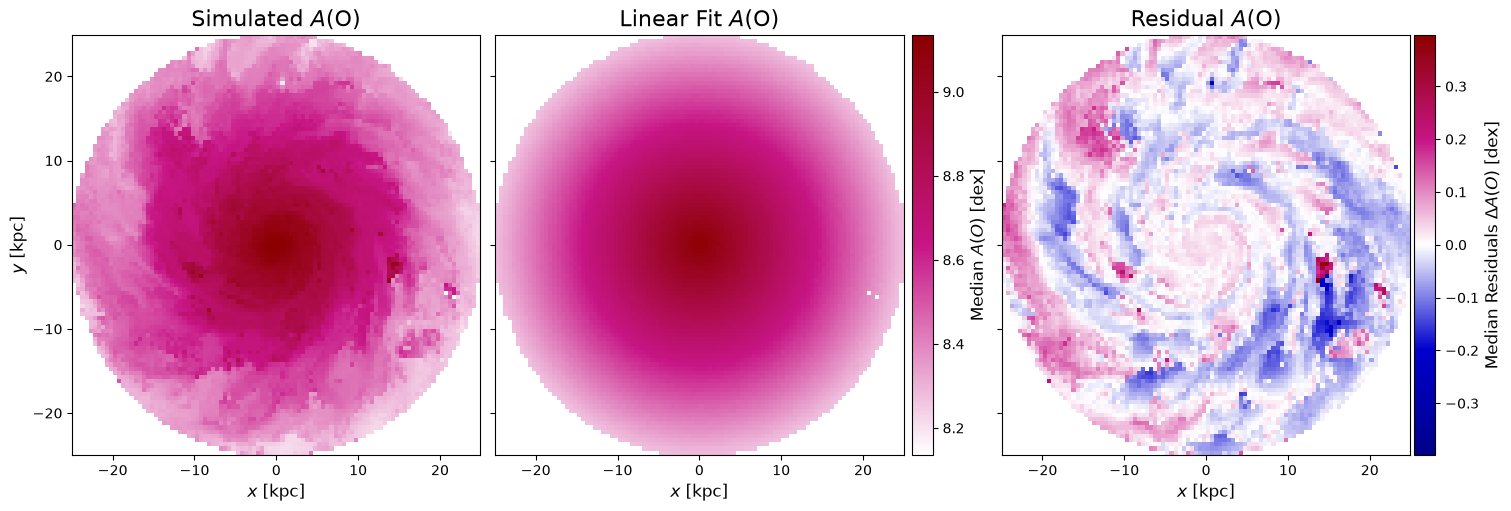

In [96]:
# define figure with three horizontally-stacked subplots
fig, axs = plt.subplots(1, 3, figsize=(15,5), sharex=True, sharey=True, constrained_layout=True)

# set colorbar limits
vmin = np.nanmin([median_ao_data, median_ao_fit]) # find minimum values excluding NaNs
vmax = np.nanmax([median_ao_data, median_ao_fit]) # max excl NaNs
residsmax = np.nanmax(np.abs(median_ao_resids)) # abs max residuals value

# define residual (diverging) cmap
div_cmap = LinearSegmentedColormap.from_list(
    "div_cmap",
    ["darkblue", "mediumblue", "white", cmap_colours[0], cmap_colours[1]]
)

ax = axs[0] # simulation (left) panel
image = ax.pcolormesh(x_edges, y_edges, median_ao_data.T, vmin=vmin, vmax=vmax, cmap=cmap, shading="auto")
ax.set_title(r"Simulated $A(\mathrm{O})$", fontsize=16) # panel title
ax.set_ylabel(r"$y$ [kpc]", fontsize=12) # y axis label
ax.set_xlabel(r"$x$ [kpc]", fontsize=12) # x label

ax = axs[1] # linear fit (centre) panel
image = ax.pcolormesh(x_edges, y_edges, median_ao_fit.T, vmin=vmin, vmax=vmax, cmap=cmap, shading="auto")
ax.set_title(r"Linear Fit $A(\mathrm{O})$", fontsize=16) # panel title
ax.set_xlabel(r"$x$ [kpc]", fontsize=12) # x label
cbar1 = fig.colorbar(image, ax=axs[:2], pad=0.01)
cbar1.set_label(r"Median $A(O)$ [dex]", fontsize=12)

ax = axs[2] # residuals (right) panel
image = ax.pcolormesh(x_edges, y_edges, median_ao_resids.T, vmin=-residsmax, vmax=residsmax, cmap=div_cmap, shading="auto")
ax.set_title(r"Residual $A(\mathrm{O})$", fontsize=16) # panel title
ax.set_xlabel(r"$x$ [kpc]", fontsize=12) # x label
cbar1 = fig.colorbar(image, ax=axs[2], pad=0.01)
cbar1.set_label(r"Median Residuals $\Delta A(O)$ [dex]", fontsize=12)

# plt.tight_layout() # minimise whitespace around/between panels
plt.savefig("figures/q3d_galactic.png", dpi=200) # save to figures/
plt.show() # display figure